In [4]:
import numpy as np
#import ray
import matplotlib.pyplot as plt
import pythtb
import wannierberri as wberri
from wannierberri.system import System_PythTB
from pythtb import tb_model
from wannierberri.evaluate_k import evaluate_k_path
from hall_ps.hall_positional_shift import HallPositionalShift

# WannierBerri PythTB

In [5]:
def model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, t2=0.5, t3=1.0, a=1.0, c=1.0):

    a_latt = a*np.sqrt(3)
    lat = np.array([[a_latt,-0,0], [-a_latt/2, a_latt*np.sqrt(3)/2, 0], [0, 0, c]])
    orb = np.array([[0, 0, 0] , [1/3, 2/3, 0]])  
    
    #lattice = pythtb.Lattice(lat_vecs=lat, orb_vecs=orb, periodic_dirs=[0, 1, 2])
    #my_model = pythtb.TBModel(lattice)

    my_model = tb_model(3, 3, lat, orb)
    my_model.set_onsite([Delta - mu, -Delta - mu])

    
    for shift in [[0,0,0], [0, -1,0], [-1,-1,0]]:
        # nearest neighbor hoppings in-plane (t)
        my_model.set_hop(t, 0, 1, shift)
        # Vertical Hoppings (tpz)
        if tp != 0:
            for z in [1, -1]:
                my_model.set_hop( tp, 0, 1, [shift[0], shift[1],  z])


    if t3 != 0:
        # Third Neighbor Hoppings (tp)
        my_model.set_hop( t3, 1, 0, [ 2,  2,  0]) 
        my_model.set_hop( t3, 1, 0, [ 0, -1,  0])
        my_model.set_hop( t3, 1, 0, [-1,  1,  0])
        my_model.set_hop(-t3, 0, 1, [ 1,  1,  0]) 
        my_model.set_hop(-t3, 0, 1, [-2, -1,  0])
        my_model.set_hop(-t3, 0, 1, [ 0, -2,  0])


    # The tc term (Diagonal Hoppings)
    if t2 != 0:
        for shift in [[0,1,0], [1,0,0], [1,1,0]]: # Skipping [0,0,0] for diagonal
            for i in range(2):
                my_model.set_hop(t2, i, i, shift)

    return my_model

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.73205081  0.          0.        ]
 [-0.8660254   1.5         0.        ]
 [ 0.          0.          1.        ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000024FAD66D6D0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x0000024FA6CAA710> : calculator not described

--------------------------------------------------

############################################################
Ca

C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\grid\path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     2.2891 ; per K-point          0.0023 ; proc-sec per K-point          0.0023
time1 =  0.0
Totally processed 996 K-points 
run() finished
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000024FA3C46AD0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x0000024FA85B6DD0> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000024FA3C46AD0>
All calculators are compatible
Symmetrization switched o

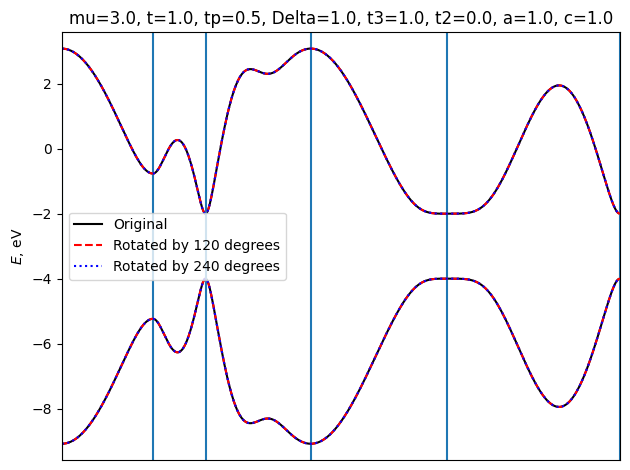

In [6]:
parameters = dict(mu=3.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.0, a=1.0, c=1.0)
model = model_ferroaxial_pythtb(**parameters)
system = System_PythTB(model)

path=wberri.Path.from_nodes(system,
        nodes=[
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
            ],
             labels=["G", "M", "K", "G", "A", "K"],
             nk = 200 )  

bands = evaluate_k_path(system, path=path)

recip_latt = system.recip_lattice
kp_cart = np.array(path.get_kpoints_cart())

rot_mat = np.array([[np.cos(np.radians(120)), -np.sin(np.radians(120)), 0],
                    [np.sin(np.radians(120)),  np.cos(np.radians(120)), 0],
                    [0, 0, 1]])

kp_cart_rot =  kp_cart @ rot_mat.T
kp_cart_rot2 = kp_cart @ rot_mat.T @ rot_mat.T

kp_latt_rot = kp_cart_rot @ np.linalg.inv(recip_latt)
kp_latt_rot2 = kp_cart_rot2 @ np.linalg.inv(recip_latt)

path_rot = wberri.Path(recip_lattice=recip_latt, k_list=kp_latt_rot)
path_rot2 = wberri.Path(recip_lattice=recip_latt, k_list=kp_latt_rot2)

bands_rot = evaluate_k_path(system, path=path_rot)
bands_rot2 = evaluate_k_path(system, path=path_rot2)

bands.plot_path_fat(path, close_fig=False, show_fig=False, label="Original", linecolor='k')
bands_rot.plot_path_fat(path_rot, linecolor='r', kwargs_line={'linestyle':'--'},label="Rotated by 120 degrees", show_fig=False, close_fig=False)
bands_rot2.plot_path_fat(path_rot2, linecolor='b', kwargs_line={'linestyle':':'},label="Rotated by 240 degrees", show_fig=False, close_fig=False)
plt.title(", ".join([f"{key}={value}" for key, value in parameters.items()]))
plt.legend()
plt.tight_layout()
filename = "ferroaxial_bands" + "_".join([f"{key}={value:.3f}" for key, value in parameters.items()]) + ".pdf"
plt.savefig(filename)
plt.show()


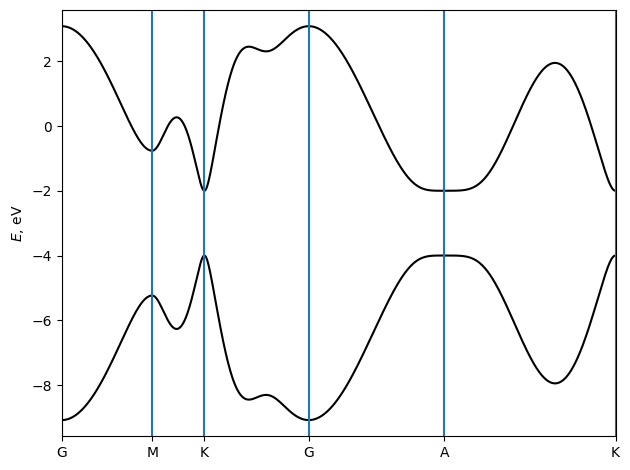

In [4]:
bands.plot_path_fat(path, close_fig=False, show_fig=False)
#plt.title(f"μ={my_model.mu}, t={my_model.t}, t'={my_model.tp}, Δ={my_model.Delta}, t'z={my_model.tpz}, tc={my_model.tc}")
plt.tight_layout()
plt.savefig('par1.pdf')
plt.show()

# Positional Shift

In [5]:
import matplotlib as mpl

# TR-symmetric

In [7]:
system_sym_TR = System_PythTB(ptb_model=model_ferroaxial_pythtb(mu=3.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.0, a=1.0, c=1.0))
system_sym_TR.set_pointgroup(symmetry_gen=["C3z", "TimeReversal"])

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.73205081  0.          0.        ]
 [-0.8660254   1.5         0.        ]
 [ 0.          0.          1.        ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


In [11]:
tetra = True
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[16, 16, 16], NKFFT=[2, 2, 2])

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system_sym_TR,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb-TR-sym-tetra',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x000001DD30FB0450>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x000001DD30FB3AD0>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x000001DD30FB0450>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x000001DD30FB3AD0>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[16 16 16], NKFFT=[2 2 2], NKtot=[32 32 32]
generating K_list
Done in 0.06902217864990234 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.3618130683

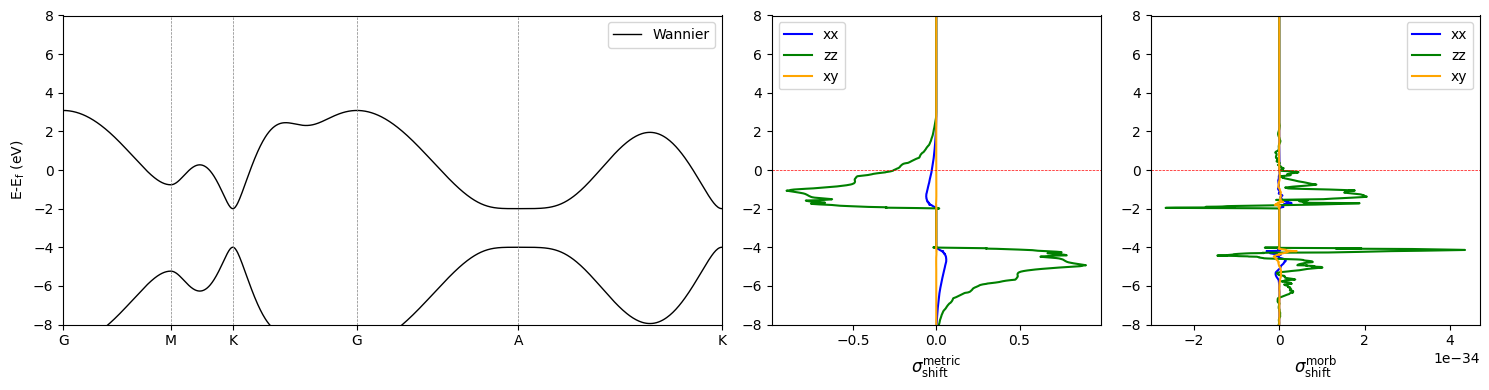

In [12]:
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.savefig("ferro_bands_cond_pos_C3z_TR.pdf")

# k-resolved

In [9]:
from wannierberri.formula.covariant import QuantumMetric_ab
from wannierberri.formula.covariant import DerQuantumMetric_ab_d
from hall_ps.hall_positional_shift import HallPositionalShift

target_bands = [0, 1] 

Efermi = np.linspace(-10, +10, 1601)

path_sym_TR=wberri.Path.from_nodes(system_sym_TR,
        nodes=[
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
            ],
             labels=["G", "M", "K", "G", "A", "K"],
             nk = 200 )  

tabulator =wberri.calculators.TabulatorAll(
    {
        "energy": wberri.calculators.tabulate.Energy(),
        "g": wberri.calculators.static.StaticCalculator(Formula=QuantumMetric_ab, Efermi = Efermi, fder = 2),
        "dg_dk": wberri.calculators.static.StaticCalculator(Formula=DerQuantumMetric_ab_d, Efermi = Efermi, fder = 2),
        "pos_shift": HallPositionalShift(Efermi = Efermi),
        "Omega" : wberri.calculators.tabulate.BerryCurvature(),
    }
)
tabulator =wberri.calculators.TabulatorAll(
    {
          'pos_shift_calc' : HallPositionalShift(Efermi=Efermi, k_resolved=True, kwargs_formula={"morb_part": True, "external_terms": False})
    }
)

type(tabulator).allow_path = property(lambda self: True)

result = wberri.run(
    system=system_sym_TR,
    grid=path_sym_TR,
    calculators={"tab": tabulator},
    #calculators = {"tabulate" : tabulator},
    print_Kpoints=True
)

Starting run()
Using the follwing calculators : 
############################################################

 'tab'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000024FAD6064D0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "pos_shift_calc" : <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000024FAD821250> : calculator not described

 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x0000024FAD604790> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tab <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000024FAD6064D0>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 996 points

C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\grid\path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


                 700              5.0                   2.1                   7.2
time for processing    996 K-points on   1 processes:     7.3240 ; per K-point          0.0074 ; proc-sec per K-point          0.0074
time1 =  0.0
setting the grid
setting new kpoints
finding equivalent kpoints


C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\result\tabresult.py:155: UserWarning: k-point 1=[0.00251256 0.         0.        ] is not on the grid, skipping.
  warnings.warn(f"k-point {ik}={self.kpoints[ik]} is not on the grid, skipping.")
C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\result\tabresult.py:155: UserWarning: k-point 2=[0.00502513 0.         0.        ] is not on the grid, skipping.
  warnings.warn(f"k-point {ik}={self.kpoints[ik]} is not on the grid, skipping.")
C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\result\tabresult.py:155: UserWarning: k-point 3=[0.00753769 0.         0.        ] is not on the grid, skipping.
  warnings.warn(f"k-point {ik}={self.kpoi

collecting


ZeroDivisionError: division by zero

In [ ]:
import wannierberri as wberri
from wannierberri.calculators.static import StaticCalculator, Energy

data = result["tab"].data

energy = data["E"]          # Shape: (nk, nbands)
orbital_moment = data["M"]  # Shape: (nk, nbands, 3)     -> Vector (Mx, My, Mz)
metric = data["g"]          # Shape: (nk, nbands, 3, 3)  -> Tensor (g_xx, g_xy, etc.)
metricDer = data["dg_dk"]        
omega = data["Omega"]        
pos_shift = data["pos_shift"]      

# Define the bands to track
target_bands = [0, 1] 

# 3. Build the Tabulator using StaticCalculator + Formula combinations
tabulator = wberri.calculators.Tabulator(
    calculators={
        # Standard Property: Energy (This one has its own dedicated calculator)
        "E": Energy(ibands=target_bands),
        
        # Standard Property: Orbital Moment
        "M": StaticCalculator(Formula=M_ln, ibands=target_bands),
        
        # Standard Property: Quantum Metric
        "g": StaticCalculator(Formula=QuantumMetric_ab, ibands=target_bands),
        
        # --- FROM THE CUSTOM SCRIPT ---
        # The k-derivative of the Quantum Metric (used in metric_part)
        "dg_dk": StaticCalculator(Formula=DerQuantumMetric_ab_d, ibands=target_bands),
        
        # The FULL k-resolved Hall Positional Shift evaluated over the path!
        "pos_shift": HallPositionalShift(morb_part=True, metric_part=True, ibands=target_bands)
    }
)

# Run it on your path or grid
result = wberri.run(
    system=system,
    grid=path,
    calculators={"tab": tabulator},
    print_Kpoints=False
)

In [ ]:
# --- Example: Plotting the Z-component of the Orbital Moment for Band 0 ---
k_axis = path.get_k_axis() # Get the 1D distance along the path for the X-axis

plt.figure(figsize=(8, 5))
plt.plot(k_axis, energy[:, 0], label="Energy (Band 0)", color='black', linestyle='--')
plt.plot(k_axis, orbital_moment[:, 0, 2], label="$M_z$ (Band 0)", color='blue')

# Formatting the plot with high-symmetry labels
plt.xticks(path.get_ticks()[0], path.get_ticks()[1])
plt.ylabel("Property Value")
plt.title("Band 0: Energy and Z-Orbital Moment along Path")
plt.axhline(0, color='gray', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Example: Extracting the xx component of the Quantum Metric ---
# metric[:, 0, 0, 0] represents: [all_k_points, band_0, x_direction, x_direction]
g_xx_band0 = metric[:, 0, 0, 0]